In [13]:
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, sisal_utils as sutils, utils
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 
import json
import os 
import plotly.io as pio
pio.renderers.default = "vscode"
sns.set_style('dark')

In this notebook, we compare variograms of itrace and sisal data. In particular, we select itrace data with the union of circles centered around sisal points at each time slice.

Hence, we developped a function that automatically defines the mask, compute sisal and itrace variograms and save the results.

In [35]:
params = {'trend': 'multiple_linear_latabs_latReLU_P',
          'trend_before_mask': True,
          'maxlag': 1.2e7,
          'nlags': 20,
          'centers': None,
          'tolerance' : 22.5,
          'mask radius [km]': 1000,
          'res [months]': 12,
          'Itrace simulation spec' : {'time':'20kyrBP',},
          'countries':None
          }
data_cols = {'lat':'lat',
             'lon':'lon',
             'quantity':'d18Op'}

fp = f"../output/variograms/itrace/sim{params['Itrace simulation spec']['time']}/res{params['res [months]']}/maxlag{str(int(params['maxlag']))}nlags{params['nlags']}/trend_{params['trend']}/"
if not os.path.exists(fp) :
    os.makedirs(fp)

verbose =  False

In [36]:
# Load sisal data 
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [months]']/12),countries=params['countries'],verbose=verbose)
# load itrace data
itrace_data = gutils.get_preprocessed_itrace_data(res=params['res [months]'],P=True,format='xr',verbose=False,
                                            sim_prefix = 'b.e13.Bi1850C5.f19_g16',
                                            sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
                                            sim_forcings='ice_ghg_orb_wtr',
                                            sim_kyr= int(params['Itrace simulation spec']['time'][:2]),
                                            sim_num='01',
                                            sim_model='clm2.h0',
                                            ) # xr


loading sisal data
sisal dataframe is ready
loading itrace files


#### **Mask iTrace data around SISAL points**

In [ ]:
sisal_df = gutils.get_sisal_data_for_kriging(res=int(params['res [months]']/12),countries=params['countries'],verbose=verbose)

itrace_df = gutils.get_preprocessed_itrace_data(res=params['res [months]'],P=True,format='df',verbose=False,
                                            sim_prefix = 'b.e13.Bi1850C5.f19_g16',
                                            sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
                                            sim_forcings='ice_ghg_orb_wtr',
                                            sim_kyr= 20,
                                            sim_num='01',
                                            sim_model='clm2.h0',
                                            ) # pd df

In [ ]:
itrace_masked_df,_ = utils.mask_union_of_circles_around_pts(itrace_df,sisal_df,params['mask radius [km]'],verbose=True) # type:ignore

In [4]:
fig = putils.plot_global_map(data=itrace_df.groupby(['time']).mean().reset_index(),
                    quantity_col=data_cols['quantity'],
                    title = 'masked itrace data',
                    quantity=data_cols['quantity'],
                    unit='per mil (VSMOW)',
                    proj=False,
                    symbol='square',
                    size=3,
                    lat_col=data_cols['lat'],
                    lon_col=data_cols['lon'])

# fig.write_html("map.html", auto_open=True)
fig.show()

NameError: name 'itrace_df' is not defined

#### **Compute variograms**

In [37]:
for azimuth in [None] : #None,0,45,90,135
    print(f'computation dir={azimuth}')
    params['direction']=azimuth
    gutils.iterate_and_aggregate_variograms(data_ds = itrace_data, #type:ignore
                                        fp=fp,
                                        config_dict=params,
                                        data_cols=data_cols,
                                        mask_pts = sisal_df, # type:ignore
                                        verbose = verbose
                                       )

computation dir=None


100%|██████████| 1000/1000 [10:05<00:00,  1.65it/s]


outputs saved in folder ../output/variograms/itrace/sim20kyrBP/res12/maxlag12000000nlags20/trend_multiple_linear_latabs_latReLU_P/, files vario_df.csv and trend_metrics.json


In [38]:
dict_dfs= {
           'i_all': {'df': pd.read_csv(fp+'vario_df.csv')},
        #    'i_0': {'df': pd.read_csv(fp+'d0vario_df.csv')},
        #    'i_45': {'df': pd.read_csv(fp+'d45vario_df.csv')},
        #    'i_90': {'df': pd.read_csv(fp+'d90vario_df.csv')},
        #    'i_135': {'df': pd.read_csv(fp+'d135vario_df.csv')}
        }

model_name = 'spherical'

for key in dict_dfs.keys():
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bins=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count']
                                                                                ) 

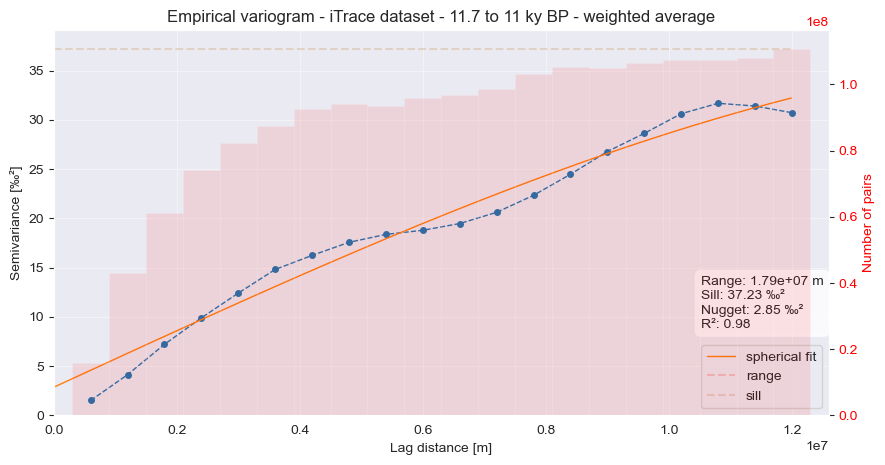

In [39]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                          counts=dict_dfs['i_all']['df']['count'],
                                          min_pairs=20,
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(10,5),
                                          save_name=fp+'fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

KeyError: 'i_0'

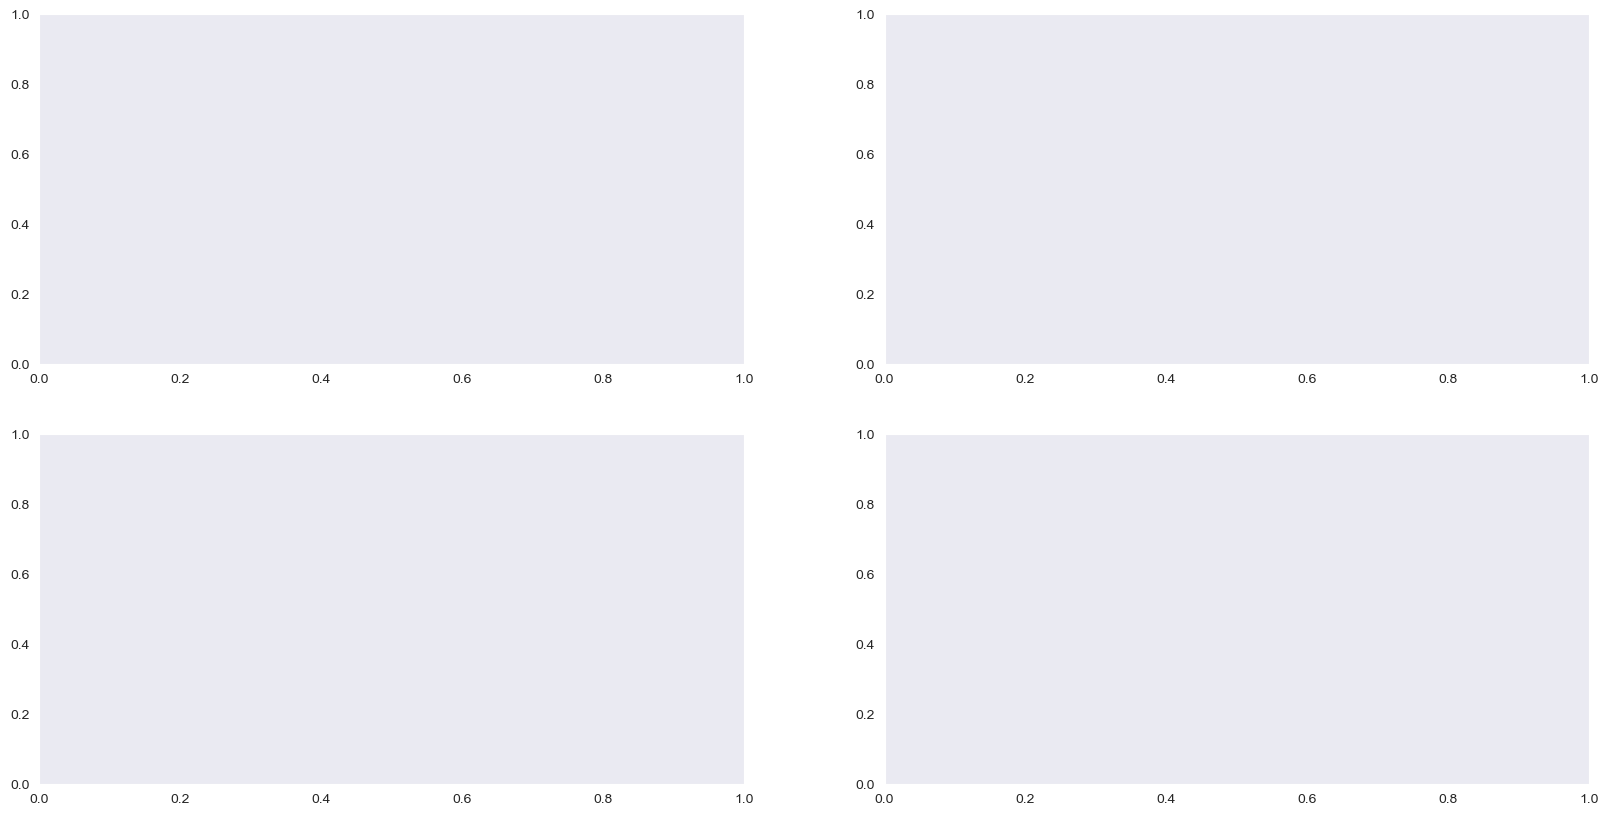

In [40]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            time='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            min_pairs=20,
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r :.2e} m')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

### Visualize metrics of trend fitting 

In [28]:
import json
with open(fp+'trend_metrics.json', 'r') as f:
    results_dict = json.load(f)

In [29]:
import numpy as np
list_df =[]
metrics_dict = {}
for i,t in enumerate(list(results_dict.keys())):
    df = gutils.multiple_linear_result_dict_to_df(results_dict[t])
    df['time']=float(t)
    df['r2']=results_dict[t]['r2']
    df['r2adj']=results_dict[t]['adj_r2']
    df['mae']=results_dict[t]['mae']
    list_df.append(df)
    


result_df = pd.concat(list_df).reset_index(drop=True)

In [30]:
print(results_dict.keys())

dict_keys(['0.0', '12.0', '24.0', '36.0', '48.0', '60.0', '72.0', '84.0', '96.0', '108.0', '120.0', '132.0', '144.0', '156.0', '168.0', '180.0', '192.0', '204.0', '216.0', '228.0', '240.0', '252.0', '264.0', '276.0', '288.0', '300.0', '312.0', '324.0', '336.0', '348.0', '360.0', '372.0', '384.0', '396.0', '408.0', '420.0', '432.0', '444.0', '456.0', '468.0', '480.0', '492.0', '504.0', '516.0', '528.0', '540.0', '552.0', '564.0', '576.0', '588.0', '600.0', '612.0', '624.0', '636.0', '648.0', '660.0', '672.0', '684.0', '696.0', '708.0', '720.0', '732.0', '744.0', '756.0', '768.0', '780.0', '792.0', '804.0', '816.0', '828.0', '840.0', '852.0', '864.0', '876.0', '888.0', '900.0', '912.0', '924.0', '936.0', '948.0', '960.0', '972.0', '984.0', '996.0', '1008.0', '1020.0', '1032.0', '1044.0', '1056.0', '1068.0', '1080.0', '1092.0', '1104.0', '1116.0', '1128.0', '1140.0', '1152.0', '1164.0', '1176.0', '1188.0', '1200.0', '1212.0', '1224.0', '1236.0', '1248.0', '1260.0', '1272.0', '1284.0', '12

In [31]:
result_df[['name','beta','std_error','p_value','vif','partial r2','r2','r2adj','mae']]

,name,beta,std_error,p_value,vif,partial r2,r2,r2adj,mae
0,intercept,5.782747,2.610362e-01,9.602933e-105,NaN,NaN,0.875853,0.875754,4.257067
1,|lat|,-0.497494,3.901927e-03,0.000000e+00,4.284885,0.322904,0.875853,0.875754,4.257067
2,latReLU,0.109139,2.833603e-03,2.059463e-291,2.712776,0.029467,0.875853,0.875754,4.257067
3,ele,-0.003937,8.933463e-05,0.000000e+00,2.937612,0.038583,0.875853,0.875754,4.257067
4,D,-0.000002,1.624837e-07,2.812397e-34,2.309983,0.002996,0.875853,0.875754,4.257067
...,...,...,...,...,...,...,...,...,...
5995,|lat|,-0.520010,3.819520e-03,0.000000e+00,4.283718,0.333486,0.887552,0.887462,4.193826
5996,latReLU,0.119112,2.776468e-03,0.000000e+00,2.723704,0.033113,0.887552,0.887462,4.193826
5997,ele,-0.004196,8.772309e-05,0.000000e+00,2.937257,0.041164,0.887552,0.887462,4.193826
5998,D,-0.000002,1.597473e-07,4.362971e-41,2.303975,0.003290,0.887552,0.887462,4.193826
